In [24]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

#sklearn
from sklearn.svm import SVC 
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn import metrics
from sklearn.metrics import confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score

# =========================
# Qiskit (WORKING – 0.45.2)
# =========================

from qiskit import QuantumCircuit
from qiskit.utils import algorithm_globals
from qiskit.circuit import Parameter
from qiskit.circuit.library import ZZFeatureMap, ZFeatureMap, TwoLocal, RealAmplitudes

from qiskit_aer import AerSimulator

from qiskit_machine_learning.algorithms import QSVC, NeuralNetworkClassifier
from qiskit_machine_learning.kernels import QuantumKernel
from qiskit_machine_learning.neural_networks import CircuitQNN
from qiskit_machine_learning.exceptions import QiskitMachineLearningError

from qiskit.algorithms.optimizers import SPSA, L_BFGS_B, COBYLA

from IPython.display import clear_output
from typing import Union


from qiskit.primitives import Sampler
from qiskit_machine_learning.neural_networks import CircuitQNN


import warnings
warnings.filterwarnings('ignore')


In [25]:
import sys
print(sys.executable)



d:\PROJECT\kkkk\qml_env\Scripts\python.exe


In [26]:
data = pd.read_csv('Cleveland Dataset.csv')
print(data.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [27]:
print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [28]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Heart Disease Distribution

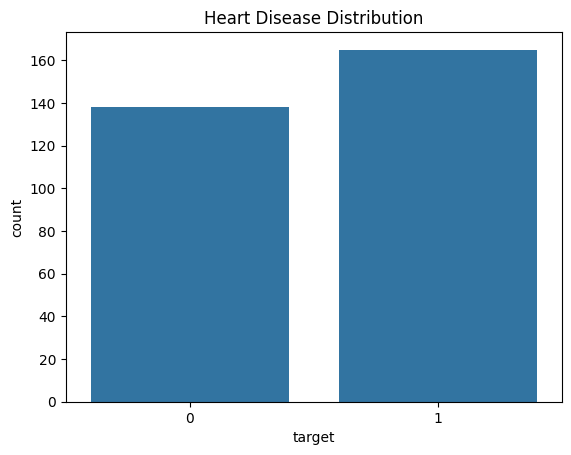

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target',data=data)
plt.title("Heart Disease Distribution")
plt.show()

## Feature Correlation Heatmap

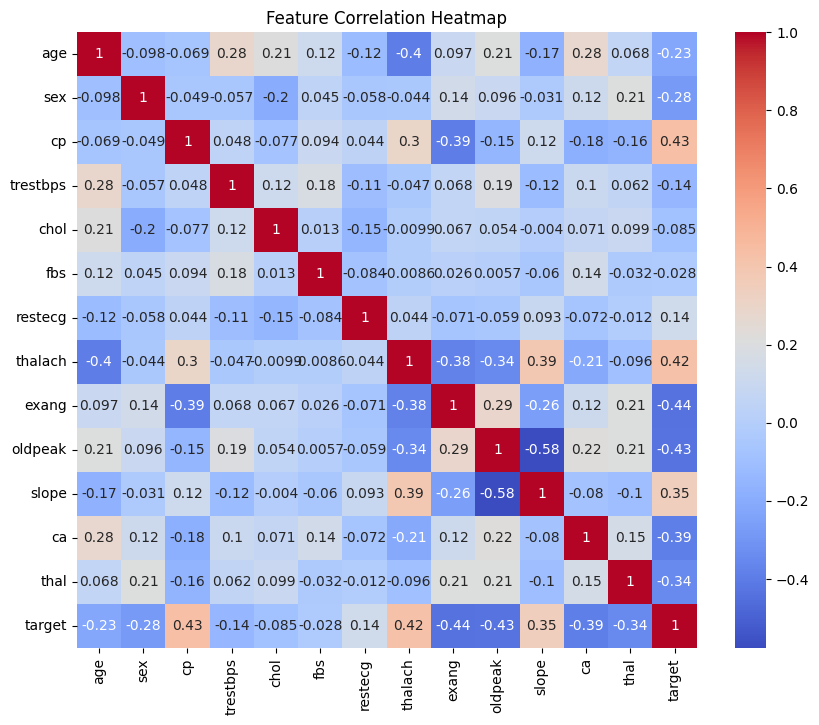

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature selection

In [31]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

X = data.drop(['target'] ,axis="columns")
y = data['target']

estimator = SVC(kernel="linear")
selector = RFE(estimator, n_features_to_select=6, step=1)
selector = selector.fit(X, y)

In [32]:
from operator import itemgetter
features = X.columns.to_list()
for x, y in (sorted(zip(selector.ranking_ , features), key=itemgetter(0))):
    print(x, y)

1 sex
1 cp
1 exang
1 slope
1 ca
1 thal
2 oldpeak
3 restecg
4 fbs
5 thalach
6 trestbps
7 age
8 chol


<function matplotlib.pyplot.show(close=None, block=None)>

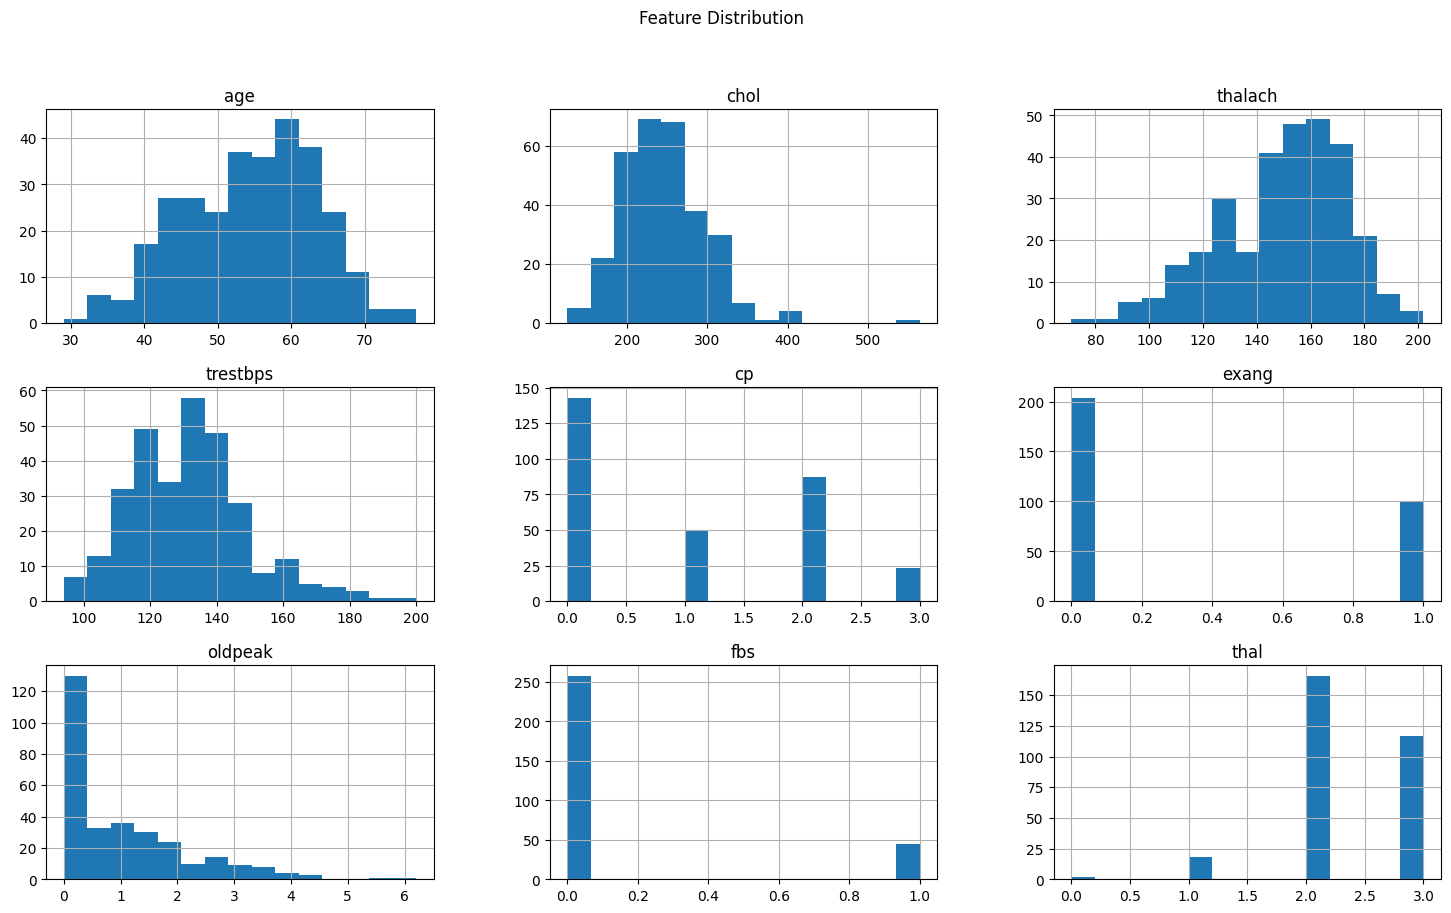

In [33]:
features =['age', 'chol', 'thalach','trestbps','cp','exang','oldpeak','fbs', 'thal']
data[features].hist(figsize=(18,10), bins=15)
plt.suptitle("Feature Distribution")
plt.show

In [34]:
corr_with_target=data.corr()['target'].sort_values(ascending=False)
print(corr_with_target)

target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64


# Classical classifiers 

## SVM

In [35]:
# =========================
# Support vector machine (SVM) 
# =========================

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


X = data[['fbs', 'restecg']]  
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Underfitted SVM
ClassifierSVM = SVC(
    kernel='rbf',
    C=0.1,                    
    gamma=0.5,                
    class_weight='balanced'   
)
ClassifierSVM.fit(X_train, y_train)
y_pred_svm = ClassifierSVM.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Classical SVC Accuracy: {svm_accuracy*100:.2f}%")


Classical SVC Accuracy: 47.54%


### SVM performance

In [36]:
# classification report of SVM
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

expected_y  = y_test
predicted_y = ClassifierSVM.predict(X_test)

svm_acc = accuracy_score(expected_y, predicted_y)


# print accuracy, classification report and confusion matrix for svm classifier
print(f"Classical SVC Accuracy: {svm_acc*100:.2f}%")
print("Classification report: \n", metrics.classification_report(expected_y, predicted_y))
print("Confusion matrix: \n", metrics.confusion_matrix(expected_y, predicted_y))

Classical SVC Accuracy: 47.54%
Classification report: 
               precision    recall  f1-score   support

           0       0.48      1.00      0.64        29
           1       0.00      0.00      0.00        32

    accuracy                           0.48        61
   macro avg       0.24      0.50      0.32        61
weighted avg       0.23      0.48      0.31        61

Confusion matrix: 
 [[29  0]
 [32  0]]


### SVM--Confusion Matrix

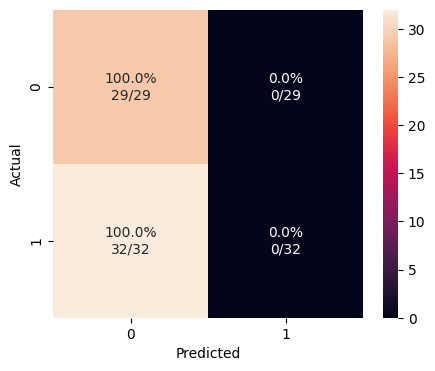

In [37]:
# confusion matrix of SVM
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)): 
    if ymap is not None: 
        y_pred = [ymap[yi] for yi in y_pred] 
        y_true = [ymap[yi] for yi in y_true] 
        labels = [ymap[yi] for yi in labels]
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)): 
    if ymap is not None: 
        y_pred = [ymap[yi] for yi in y_pred] 
        y_true = [ymap[yi] for yi in y_true] 
        labels = [ymap[yi] for yi in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels) 
    cm_sum = np.sum(cm, axis=1, keepdims=True) 
    cm_perc = cm / cm_sum.astype(float) * 100 

    annot = np.empty_like(cm).astype(str) 
    nrows, ncols = cm.shape 

    for i in range(nrows): 
        for j in range(ncols): 
            c = cm[i, j] 
            p = cm_perc[i, j] 
            s = cm_sum[i][0]

            if c == 0:
                annot[i, j] = '0.0%%\n0/%d' % s
            else:
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)

    cm = pd.DataFrame(cm, index=labels, columns=labels) 
    cm.index.name = 'Actual' 
    cm.columns.name = 'Predicted' 

    fig, ax = plt.subplots(figsize=figsize) 
    sns.heatmap(cm, annot=annot, fmt='', ax=ax) 

cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4)) 

### SVM--ROC Curve

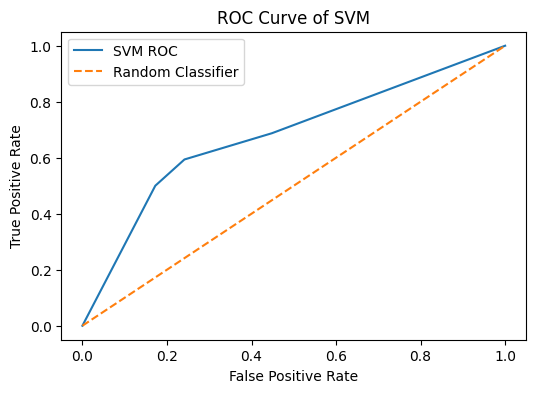

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get decision scores instead of class labels
svm_scores = ClassifierSVM.decision_function(X_test)

# ROC values
fper, tper, thresholds = roc_curve(expected_y, svm_scores)
roc_auc = auc(fper, tper)

# Plot ROC
plt.figure(figsize=(6,4))
plt.plot(fper, tper, label='SVM ROC ' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of SVM')
plt.legend()
plt.show()


## ANN

In [39]:
# Also known as classical QNN 
X = data[['fbs', 'restecg']]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = MLPClassifier(max_iter=1000,  random_state=5)
model = model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Classical ANN Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

Classical ANN Accuracy: 57.38%


### ANN Performance

In [40]:
# classification report of ANN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

expected_y  = y_test
predicted_y = model.predict(X_test) 

ann_acc = accuracy_score(expected_y, predicted_y)
print(f"Classical ANN Accuracy: {ann_acc*100:.2f}%")
 

# print classification report and confusion matrix for the classifier
print("Classification report: \n", metrics.classification_report(expected_y, predicted_y))
print("Confusion matrix: \n", metrics.confusion_matrix(expected_y, predicted_y))

Classical ANN Accuracy: 57.38%
Classification report: 
               precision    recall  f1-score   support

           0       0.67      0.21      0.32        29
           1       0.56      0.91      0.69        32

    accuracy                           0.57        61
   macro avg       0.61      0.56      0.50        61
weighted avg       0.61      0.57      0.51        61

Confusion matrix: 
 [[ 6 23]
 [ 3 29]]


### ANN--Confusion Matrix

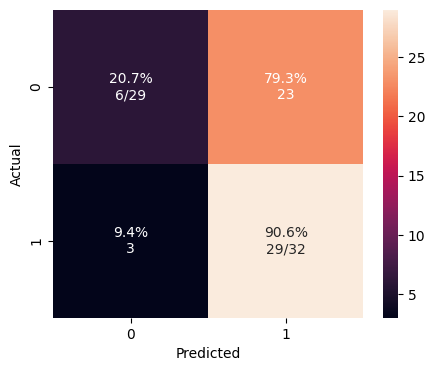

In [41]:
# confusion matrix of ANN
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)): 
    if ymap is not None: 
        y_pred = [ymap[yi] for yi in y_pred] 
        y_true = [ymap[yi] for yi in y_true] 
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels) 
    cm_sum = np.sum(cm, axis=1, keepdims=True) 
    cm_perc = cm / cm_sum.astype(float) * 100 
    annot = np.empty_like(cm).astype(str) 
    nrows, ncols = cm.shape 
    for i in range(nrows): 
        for j in range(ncols): 
            c = cm[i, j] 
            p = cm_perc[i, j] 
            if i == j: 
                s = cm_sum[i] 
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s) 
            elif c == 0: 
                annot[i, j] = '' 
            else: 
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels) 
    cm.index.name = 'Actual' 
    cm.columns.name = 'Predicted' 
    fig, ax = plt.subplots(figsize=figsize) 
    sns.heatmap(cm, annot=annot, fmt='', ax=ax) 
    
cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4)) 

### ANN--ROC Curve

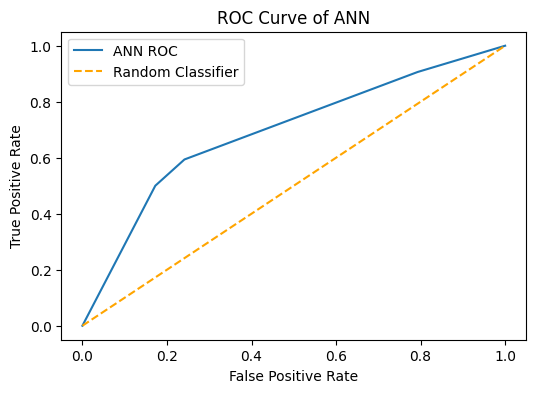

In [42]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for positive class
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fper, tper, thresholds = roc_curve(expected_y, y_prob)
roc_auc = auc(fper, tper)

# Plot ROC
plt.figure(figsize=(6,4))
plt.plot(fper, tper, label='ANN ROC ')
plt.plot([0, 1], [0, 1], linestyle='--',color='orange', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of ANN')
plt.legend()
plt.show()


# Quantum classifiers 

   ## QSVC

In [43]:
X = data[['ca','cp','thal','exang','slope']]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

samples = np.append(X_train, X_test, axis=0)
minmax_scaler = MinMaxScaler((0, 1)).fit(samples)
X_train = minmax_scaler.transform(X_train)
X_test = minmax_scaler.transform(X_test)

In [44]:
# number of qubits is equal to the number of features
num_qubits = 5
# regularization parameter
C = 1000

In [45]:
from qiskit_aer import AerSimulator
from qiskit.utils import algorithm_globals
from qiskit.circuit.library import ZFeatureMap
from qiskit_machine_learning.kernels import QuantumKernel
from qiskit_machine_learning.algorithms import QSVC

algorithm_globals.random_seed = 12345

backend = AerSimulator(method="statevector")

feature_map = ZFeatureMap(feature_dimension=num_qubits, reps=2)
qkernel = QuantumKernel(feature_map=feature_map, quantum_instance=backend)

qsvc = QSVC(quantum_kernel=qkernel, C=C)


In [ ]:
# training
qsvc.fit(X_train,y_train)

# testing
qsvc_score = qsvc.score(X_test, y_test)
print(f"QSVC classification test score: {qsvc_score*100:.2f}%")


### QSVC performance

In [ ]:
# classification report of QSVC
expected_y  = y_test
predicted_y = qsvc.predict(X_test) 

# print classification report and confusion matrix for the classifier
print("Classification report: \n", metrics.classification_report(expected_y, predicted_y))
print("Confusion matrix: \n", metrics.confusion_matrix(expected_y, predicted_y))

Classification report: 
               precision    recall  f1-score   support

           0       0.62      0.79      0.70        29
           1       0.75      0.56      0.64        32

    accuracy                           0.67        61
   macro avg       0.69      0.68      0.67        61
weighted avg       0.69      0.67      0.67        61

Confusion matrix: 
 [[23  6]
 [14 18]]


### QSVC--Confusion Matrix

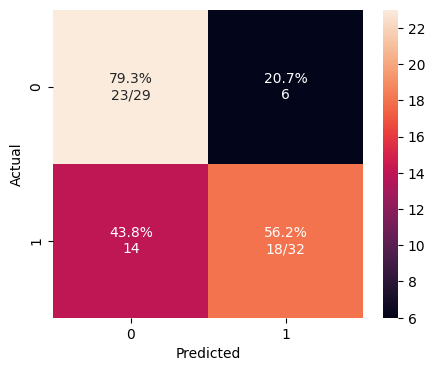

In [ ]:
# confusion matrix of QSVC
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)): 
    if ymap is not None: 
        y_pred = [ymap[yi] for yi in y_pred] 
        y_true = [ymap[yi] for yi in y_true] 
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels) 
    cm_sum = np.sum(cm, axis=1, keepdims=True) 
    cm_perc = cm / cm_sum.astype(float) * 100 
    annot = np.empty_like(cm).astype(str) 
    nrows, ncols = cm.shape 
    for i in range(nrows): 
        for j in range(ncols): 
            c = cm[i, j] 
            p = cm_perc[i, j] 
            if i == j: 
                s = cm_sum[i] 
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s) 
            elif c == 0: 
                annot[i, j] = '' 
            else: 
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels) 
    cm.index.name = 'Actual' 
    cm.columns.name = 'Predicted' 
    fig, ax = plt.subplots(figsize=figsize) 
    sns.heatmap(cm, annot=annot, fmt='', ax=ax) 
    
cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4)) 

### QSVC--ROC Curve

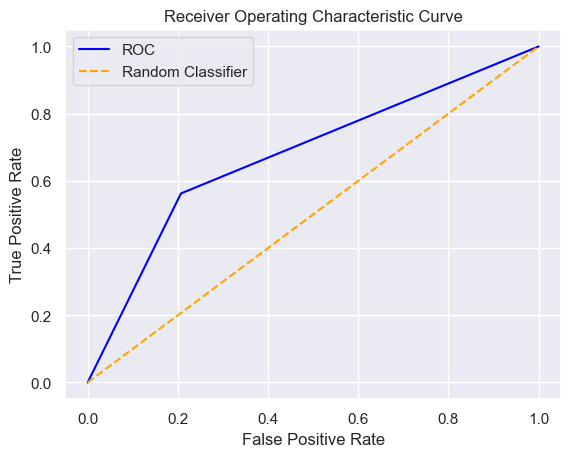

In [ ]:
# ROC curve of QSVC
import seaborn as sns
sns.set_theme()



def plot_roc_curve(fper, tper):
    plt.plot(fper, tper, color='blue', label='ROC')
    plt.plot([0, 1], [0, 1], color='orange', linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic Curve')
    plt.legend()
    plt.show()
    
fper, tper, thresholds = roc_curve(expected_y, predicted_y)
plot_roc_curve(fper, tper)

## QNN

In [ ]:
algorithm_globals.random_seed = 42
sampler = Sampler()


In [ ]:
X = data[['ca','exang','fbs', 'restecg']]
y = data['target']

std_scaler = StandardScaler().fit(X)
X = std_scaler.transform(X)
    
pca = PCA(n_components=2).fit(X)
X = pca.transform(X)

minmax_scaler = MinMaxScaler((0, 1)).fit(X)
X = minmax_scaler.transform(X)

# for cross validation
X_df = pd.DataFrame(X, columns = ['A','B'])

num_inputs = 2


In [ ]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [ ]:
# Classification with a CircuitQNN
# construct feature map
feature_map = ZFeatureMap(num_inputs)

# construct ansatz
ansatz = RealAmplitudes(num_inputs, reps=2) 

# construct quantum circuit
qc = QuantumCircuit(num_inputs)
qc.append(feature_map, range(num_inputs))
qc.append(ansatz, range(num_inputs))
qc.decompose()

In [ ]:
# parity maps bitstrings to 0 or 1
def parity(x):
    return "{:b}".format(x).count("1") % 2


output_shape = 2  # corresponds to the number of classes, possible outcomes of the (parity) mapping

In [ ]:
# =========================
# Construct QNN 
# =========================

from qiskit import Aer
from qiskit.utils import QuantumInstance
from qiskit_machine_learning.neural_networks import CircuitQNN

# Backend
backend = Aer.get_backend("aer_simulator")

# Quantum Instance 
quantum_instance = QuantumInstance(
    backend=backend,
    shots=1024,
    seed_simulator=42,
    seed_transpiler=42
)

# Parity function
def parity(x):
    return "{:b}".format(x).count("1") % 2

output_shape = 2  # binary classification

# Construct QNN
circuit_qnn = CircuitQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    interpret=parity,
    output_shape=output_shape,
    quantum_instance=quantum_instance
)

print("✅ QNN constructed successfully")



✅ QNN constructed successfully


In [ ]:
# construct classifier
circuit_classifier = NeuralNetworkClassifier(
            neural_network=circuit_qnn, optimizer= L_BFGS_B(), loss='absolute_error', callback=callback_graph
)

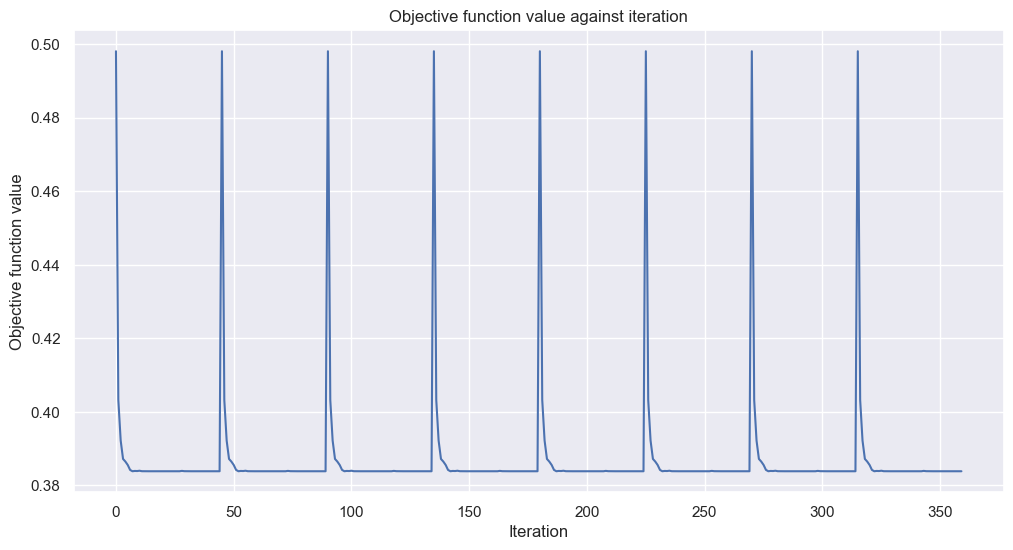

Final prediction score: [0.60526316]


In [ ]:
# cross validation
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

kf = KFold(n_splits = 8, shuffle = True, random_state= 1)
scores = []
for i in range(8):
    result = next(kf.split(X_df), None)
    x_train = X_df.iloc[result[0]]
    x_test = X_df.iloc[result[1]]
    y_train = y.iloc[result[0]]
    y_test = y.iloc[result[1]]
    circuit_classifier.fit(x_train,y_train)
    y_pred = circuit_classifier.predict(x_test)
    
plt.rcParams["figure.figsize"] = (6, 4)
print('Final prediction score: [%.8f]' % accuracy_score(y_test, y_pred))

### QNN performance

In [ ]:
# classification report of QNN
expected_y  = y_test
predicted_y = circuit_classifier.predict(x_test) 

# print accuracy, classification report and confusion matrix for the classifier
print(f"QNN Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("Classification report: \n", metrics.classification_report(expected_y, predicted_y))
print("Confusion matrix: \n", metrics.confusion_matrix(expected_y, predicted_y))

QNN Accuracy: 60.53%
Classification report: 
               precision    recall  f1-score   support

           0       0.67      0.33      0.44        18
           1       0.59      0.85      0.69        20

    accuracy                           0.61        38
   macro avg       0.63      0.59      0.57        38
weighted avg       0.62      0.61      0.58        38

Confusion matrix: 
 [[ 6 12]
 [ 3 17]]


### QNN--Confusion Matrix

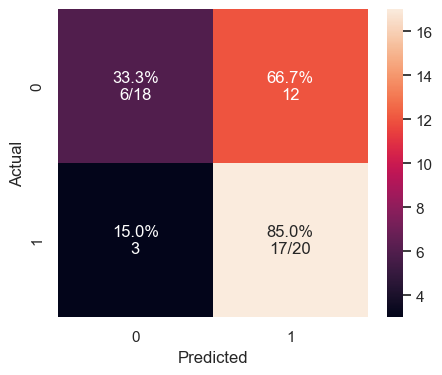

In [ ]:
# confusion matrix of QNN
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)): 
    if ymap is not None: 
        y_pred = [ymap[yi] for yi in y_pred] 
        y_true = [ymap[yi] for yi in y_true] 
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels) 
    cm_sum = np.sum(cm, axis=1, keepdims=True) 
    cm_perc = cm / cm_sum.astype(float) * 100 
    annot = np.empty_like(cm).astype(str) 
    nrows, ncols = cm.shape 
    for i in range(nrows): 
        for j in range(ncols): 
            c = cm[i, j] 
            p = cm_perc[i, j] 
            if i == j: 
                s = cm_sum[i] 
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s) 
            elif c == 0: 
                annot[i, j] = '' 
            else: 
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels) 
    cm.index.name = 'Actual' 
    cm.columns.name = 'Predicted' 
    fig, ax = plt.subplots(figsize=figsize) 
    sns.heatmap(cm, annot=annot, fmt='', ax=ax) 
    
cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4)) 

### QNN--ROC Curve

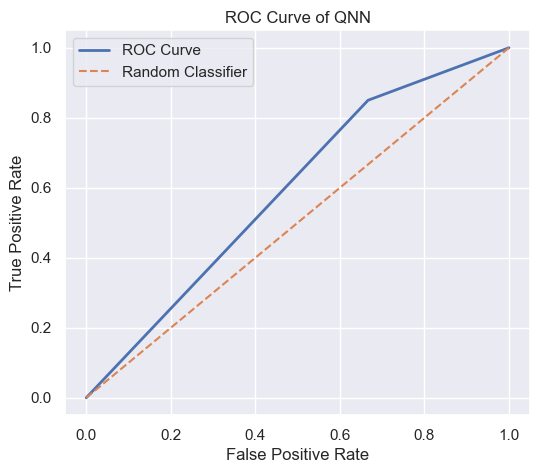

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve of QNN
def plot_roc_curve(fpr, tpr):
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label="ROC Curve", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of QNN")
    plt.legend()
    plt.grid(True)
    plt.show()

# expected_y = true labels
# predicted_y = predicted probabilities or labels

fpr, tpr, thresholds = roc_curve(expected_y, predicted_y)
plot_roc_curve(fpr, tpr)


## VQC

In [ ]:
X = data.drop(['target','chol','trestbps','age'],axis="columns")
y = data['target']

In [ ]:
# ================================
# DATA PREPROCESSING
# ================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PCA (2 components)
pca = PCA(n_components=2, random_state=42)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# Min-Max Scaling to [0,1] (important for quantum encoding)
samples = np.vstack((X_train, X_test))
minmax_scaler = MinMaxScaler((0, 1))
minmax_scaler.fit(samples)

X_train = minmax_scaler.transform(X_train)
X_test = minmax_scaler.transform(X_test)

print("Data preprocessing complete")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Data preprocessing complete
Train shape: (242, 2)
Test shape : (61, 2)


In [ ]:
# ================================
# Ensure NumPy arrays
# ================================

import numpy as np

X_train = np.asarray(X_train, dtype=float)
X_test  = np.asarray(X_test, dtype=float)

y_train = np.asarray(y_train, dtype=int).ravel()
y_test  = np.asarray(y_test, dtype=int).ravel()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Unique labels:", np.unique(y_train))


X_train shape: (242, 2)
y_train shape: (242,)
Unique labels: [0 1]


In [ ]:
# ================================
# VQC 
# ================================

from qiskit.primitives import Sampler
from qiskit.circuit.library import ZFeatureMap, TwoLocal
from qiskit.algorithms.optimizers import SPSA
from qiskit_machine_learning.algorithms import VQC
from qiskit.utils import algorithm_globals
from sklearn.metrics import accuracy_score

# -------------------------
# Parameters
# -------------------------
feature_dim = X_train.shape[1]   # after PCA = 2
algorithm_globals.random_seed = 42

# -------------------------
# Sampler (MODERN)
# -------------------------
sampler = Sampler()

# -------------------------
# Feature map & Ansatz
# -------------------------
feature_map = ZFeatureMap(feature_dimension=feature_dim, reps=2)
ansatz = TwoLocal(feature_dim, ["ry", "rz"], "cz", reps=2)

# -------------------------
# Optimizer
# -------------------------
optimizer = SPSA(maxiter=100)

# -------------------------
# VQC Model 
# -------------------------
vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer
)

# -------------------------
# Train
# -------------------------
vqc.fit(X_train, y_train)

# -------------------------
# Test
# -------------------------
y_pred_vqc = vqc.predict(X_test)

acc = accuracy_score(y_test, y_pred_vqc)
print(f"VQC Test Accuracy: {acc*100:.2f}%")


VQC Test Accuracy: 75.41%


### VOC Performance

In [ ]:
#result = vqc.run(quantum_instance)
#print("Quantum accuracy on test set: {0}%".format(round(result['testing_accuracy']*100, 2)))
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.metrics import accuracy_score

y_pred_vqc = vqc.predict(X_test)
acc = accuracy_score(y_test, y_pred_vqc)

print(f"VQC Accuracy: {acc*100:.2f}%")


print("Classification Report:\n")
print(classification_report(y_test, y_pred_vqc))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_vqc))


VQC Accuracy: 75.41%
Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.54      0.67        28
           1       0.70      0.94      0.81        33

    accuracy                           0.75        61
   macro avg       0.79      0.74      0.74        61
weighted avg       0.79      0.75      0.74        61

Confusion Matrix:

[[15 13]
 [ 2 31]]


In [ ]:
print(f"y_test shape:      {y_test.shape}")
print(f"predicted_y shape: {len(predicted_y)}")
print(f"X_test shape:      {X_test.shape}")

y_test shape:      (61,)
predicted_y shape: 38
X_test shape:      (61, 2)


### VQC--Confusion Matrix

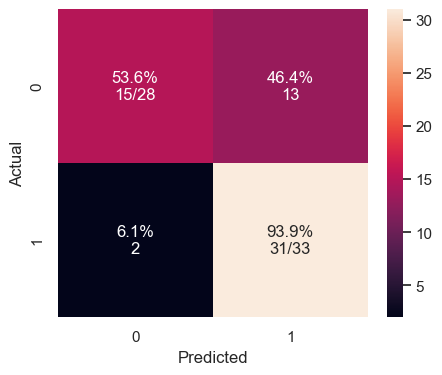

In [ ]:
# confusion matrix of VQC
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)): 
    if ymap is not None: 
        y_pred = [ymap[yi] for yi in y_pred] 
        y_true = [ymap[yi] for yi in y_true] 
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels) 
    cm_sum = np.sum(cm, axis=1, keepdims=True) 
    cm_perc = cm / cm_sum.astype(float) * 100 
    annot = np.empty_like(cm).astype(str) 
    nrows, ncols = cm.shape 
    for i in range(nrows): 
        for j in range(ncols): 
            c = cm[i, j] 
            p = cm_perc[i, j] 
            if i == j: 
                s = cm_sum[i] 
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s) 
            elif c == 0: 
                annot[i, j] = '' 
            else: 
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels) 
    cm.index.name = 'Actual' 
    cm.columns.name = 'Predicted' 
    fig, ax = plt.subplots(figsize=figsize) 
    sns.heatmap(cm, annot=annot, fmt='', ax=ax) 
    
cm_analysis(y_test, y_pred_vqc, labels=[0,1], ymap=None, figsize=(5,4)) 

### VQC--ROC Curve

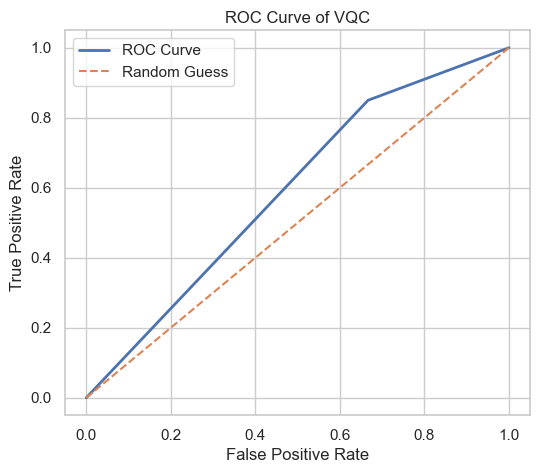

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn theme (modern & safe)
sns.set_theme(style="whitegrid")

def plot_roc_curve(fpr, tpr):
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label="ROC Curve", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of VQC")
    plt.legend()
    plt.show()

# Compute ROC
fpr, tpr, thresholds = roc_curve(expected_y, predicted_y)

# Plot
plot_roc_curve(fpr, tpr)


# Proposed model 

## Bagging-QSVC

In [ ]:
import numpy as np
import pandas as pd

#sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import BaggingClassifier

#qiskit
from qiskit import *
from qiskit.circuit.library import ZFeatureMap
from qiskit.utils import QuantumInstance, algorithm_globals
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import QuantumKernel

import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('Cleveland Dataset.csv')

In [ ]:
X = data[['ca','cp','thal','exang','slope']]
y = data['target']

# x = data[['ca','cp','thal','exang','slope'],axis="columns"]
#y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

samples = np.append(X_train, X_test, axis=0)
minmax_scaler = MinMaxScaler((0, 1)).fit(samples)
X_train = minmax_scaler.transform(X_train)
X_test = minmax_scaler.transform(X_test)

In [ ]:
# number of qubits is equal to the number of features
num_qubits = 5
# regularization parameter
C = 1000

In [ ]:
algorithm_globals.random_seed = 12345

backend = QuantumInstance(
    BasicAer.get_backend("statevector_simulator"),
    seed_simulator=algorithm_globals.random_seed,
    seed_transpiler=algorithm_globals.random_seed,
)

feature_map = ZFeatureMap(feature_dimension=num_qubits, reps=2)

qkernel = QuantumKernel(feature_map=feature_map, quantum_instance=backend)

qsvc = QSVC(quantum_kernel=qkernel, C=C)

In [ ]:
# training
qsvc.fit(X_train,y_train)

# testing
qsvc_score = qsvc.score(X_test, y_test)
print(f"QSVC classification test score: {qsvc_score*100:.2f}%")

QSVC classification test score: 88.52%


In [ ]:
# Pipeline Estimator
pipeline = make_pipeline(MinMaxScaler(), qsvc)

# Instantiate the bagging classifier
bgclassifier = BaggingClassifier(base_estimator=pipeline, n_estimators=100, 
                                 random_state=1, n_jobs=-1)

# Fit the bagging classifier
bgclassifier.fit(X_train, y_train)

# Model scores on test and training data
print(f"Model test Score: {bgclassifier.score(X_test, y_test)*100:.2f}%")
print(f"Model training Score: {bgclassifier.score(X_train, y_train)*100:.2f}%")


Model test Score: 90.16%
Model training Score: 90.08%


### Bagging-QSVC performance

In [ ]:
# classification report of Bagging-QSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

expected_y  = y_test
predicted_y = bgclassifier.predict(X_test)

# Accuracy
acc = accuracy_score(expected_y, predicted_y)
print(f"Bagging-QSVC Accuracy: {(acc*100):.2f}%")

# Classification report and confusion matrix
print("Classification report:\n", classification_report(expected_y, predicted_y))
print("Confusion matrix:\n", confusion_matrix(expected_y, predicted_y))


Bagging-QSVC Accuracy: 90.16%
Classification report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        29
           1       0.91      0.91      0.91        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Confusion matrix:
 [[26  3]
 [ 3 29]]


### Bagging-QSVC-- Confusion Matrix

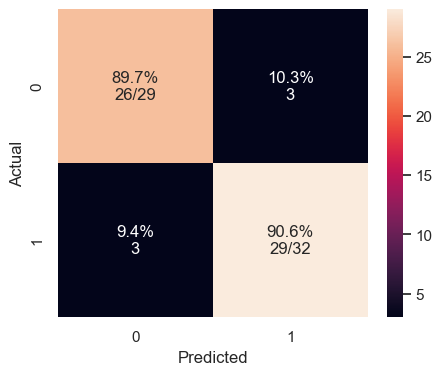

In [ ]:
# confusion matrix of Bagging-QSVC
def cm_analysis(y_true, y_pred, labels, ymap=None, figsize=(5,4)): 
    if ymap is not None: 
        y_pred = [ymap[yi] for yi in y_pred] 
        y_true = [ymap[yi] for yi in y_true] 
        labels = [ymap[yi] for yi in labels]
    cm = confusion_matrix(y_true, y_pred, labels=labels) 
    cm_sum = np.sum(cm, axis=1, keepdims=True) 
    cm_perc = cm / cm_sum.astype(float) * 100 
    annot = np.empty_like(cm).astype(str) 
    nrows, ncols = cm.shape 
    for i in range(nrows): 
        for j in range(ncols): 
            c = cm[i, j] 
            p = cm_perc[i, j] 
            if i == j: 
                s = cm_sum[i] 
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s) 
            elif c == 0: 
                annot[i, j] = '' 
            else: 
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels) 
    cm.index.name = 'Actual' 
    cm.columns.name = 'Predicted' 
    fig, ax = plt.subplots(figsize=figsize) 
    sns.heatmap(cm, annot=annot, fmt='', ax=ax) 
    
cm_analysis(y_test, predicted_y, labels=[0,1], ymap=None, figsize=(5,4)) 

### Bagging-QSVC--ROC Curve

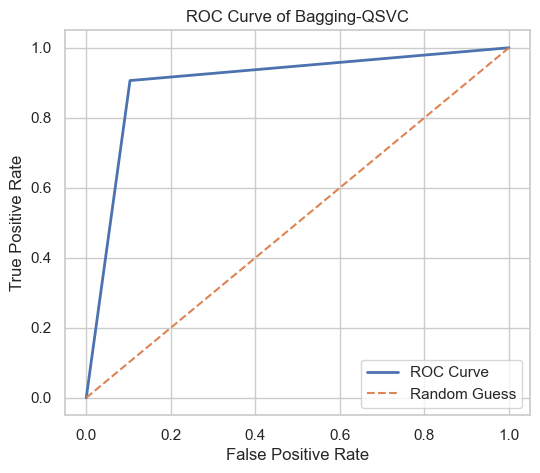

: 

In [ ]:
# ROC curve of Bagging-QSVC
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

#  Modern seaborn style (safe)
sns.set_theme(style="whitegrid")

def plot_roc_curve(fper, tper):
    plt.figure(figsize=(6, 5))
    plt.plot(fper, tper, label="ROC Curve", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of Bagging-QSVC")
    plt.legend()
    plt.show()

# Compute ROC values
fper, tper, thresholds = roc_curve(expected_y, predicted_y)

# Plot ROC
plot_roc_curve(fper, tper)
